---
title: Multiple Demand Matrices
toc: true
execute:
  enabled: true
image: image.png
---

Sometimes the population a service needs to reach isn't a single number -- a facility plan might need to work well both for the *whole* population and for a specific group with different needs, e.g. an older population who may travel less easily or use a service more often.

[The 'multiple travel matrices' example](../multiple_travel_matrices/index.ipynb) showed how to register a **secondary travel matrix** (public transport, alongside a primary car matrix) so that both modes' metrics show up side by side on the same ranked list. This example does the equivalent for **demand**: registering a secondary demand dataset alongside the primary one via `add_secondary_demand()`.

As with secondary travel matrices, a secondary demand scenario never drives site selection -- the primary demand always does. Instead, every solution `solve()` returns also carries `weighted_average__<label>` and `proportion_within_coverage_threshold__<label>` columns for each registered scenario, ready to trade off with a Pareto front or blend into the objective with `weights=`.

## Setting up the problem

We'll reuse the same Devon community diagnostic centre (CDC) sites, travel matrix and region geometry as [the weights example](../multiobjective_optimisation_weights/index.ipynb), plus the same demand dataset (`demand_MF_50_84.csv`) -- which conveniently already carries two real population figures per LSOA: `Total` population, and `MF50-84`, the population aged 50-84. We'll register `Total` as the primary demand and `MF50-84` as a secondary scenario, to see how a plan optimised for the whole population compares against one that prioritises this older age band.

We also add an illustrative `capacity` column to the sites (existing sites assumed to have more capacity than new ones) -- the CDC sample data has no real capacity figures, so this is made up purely to demonstrate `two_step_floating_catchment()`'s `demand=` argument later on.

In [1]:
import pandas as pd
from lokigi.site import SiteProblem

sites_df = pd.read_csv("../../../sample_data/devon_cdcs.csv")

# Illustrative capacity -- made up for demonstration, since the sample
# dataset has no real capacity data.
sites_df["capacity"] = sites_df["Existing"].map({"Yes": 8, "No": 4})

problem = SiteProblem()

problem.add_sites(
    sites_df,
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing",
    capacity_col="capacity",
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="Total",
    location_id_col="LSOA 2021 Name"
    )

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


Now we register the older-population figure as a **secondary demand scenario** via `add_secondary_demand()`. It takes the same `demand_col`/`location_id_col` arguments as `add_demand()`, plus a required `label` used to suffix every metric column it contributes (e.g. `label="older_population"` -> `weighted_average__older_population`).

You can register as many secondary demand scenarios as you like this way -- each one just needs its own unique `label`, and that label can't already be in use by a secondary travel matrix (they share the same suffix namespace).

In [2]:
problem.add_secondary_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="MF50-84",
    location_id_col="LSOA 2021 Name",
    label="older_population",
    )

## Mapping a demand scenario

`plot_region_geometry_layer()` also takes `demand=`, choropleth-mapping a registered secondary scenario instead of the primary demand.

<Axes: >

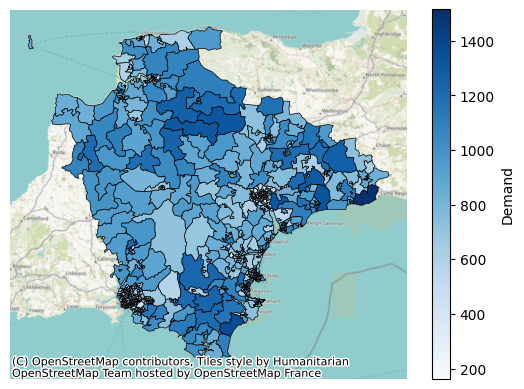

In [3]:
problem.plot_region_geometry_layer(
    plot_demand=True,
    demand="older_population",
    add_basemap=True,
)

We could plot this side-by-side with our primary demand. 

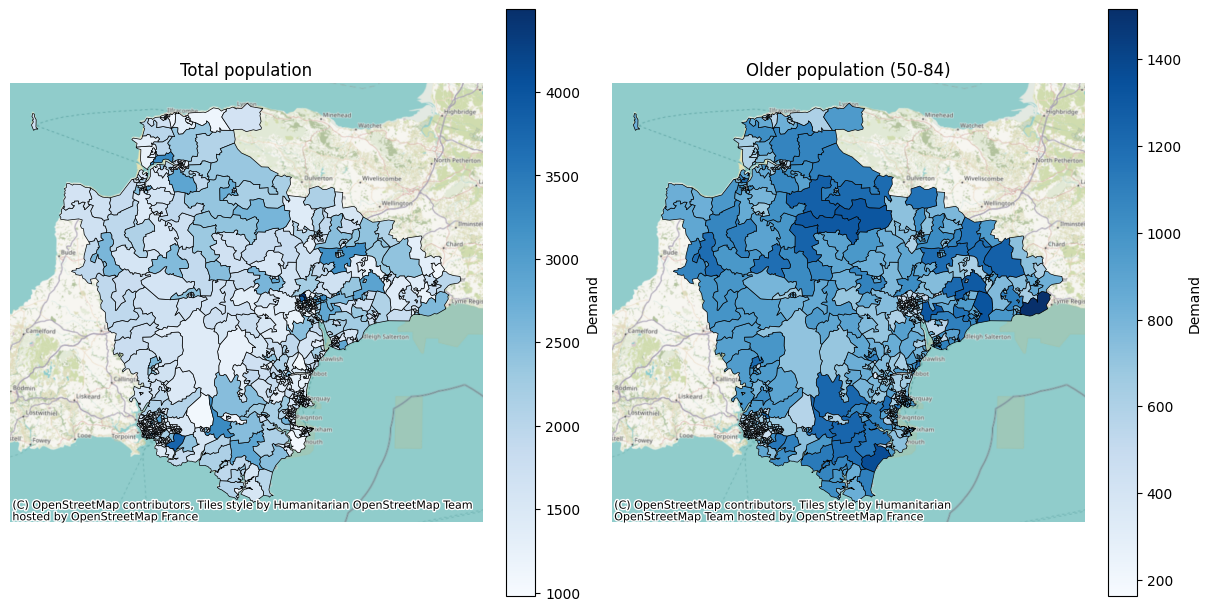

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    ncols=2,
    figsize=(12, 6),
    constrained_layout=True,
)

problem.plot_region_geometry_layer(
    ax=axes[0],
    plot_demand=True,
    add_basemap=True,
)

problem.plot_region_geometry_layer(
    ax=axes[1],
    plot_demand=True,
    demand="older_population",
    add_basemap=True,
)

axes[0].set_title("Total population")
axes[1].set_title("Older population (50-84)")

plt.show()

:::{.callout-tip}
If we wanted our legend axis to match across the plots, we would add the following:


```python
#########
# NEW
vmin = 0 
vmax = max(
    problem.secondary_demand_matrices.get('older_population')["data"]["MF50-84"].max(),
    problem.show_demand()['Total'].max(),
)
#########

fig, axes = plt.subplots(
    ncols=2,
    figsize=(12, 6),
    constrained_layout=True,
)

problem.plot_region_geometry_layer(
    ax=axes[0],
    plot_demand=True,
    add_basemap=True,
    vmin=vmin, # NEW
    vmax=vmax  # NEW
)

problem.plot_region_geometry_layer(
    ax=axes[1],
    plot_demand=True,
    demand="older_population",
    add_basemap=True,
    vmin=vmin, # NEW
    vmax=vmax # NEW
)

axes[0].set_title("Total population")
axes[1].set_title("Older population (50-84)")

plt.show()
```
:::

## Solving

Now we solve **once**, exactly as usual -- `solve()` still optimises against the primary (`Total`) demand.

In [5]:
solution = problem.solve(p=5, threshold_for_coverage=30)

  0%|          | 0/14 [00:00<?, ?it/s]

Let's look at the column names now available. Alongside the usual `Total`-demand-weighted metrics (`weighted_average`, `proportion_within_coverage_threshold`, ...), we now also get an `older_population`-suffixed sibling for each of the two metrics that actually vary with demand.

In [6]:
solution.show_solutions_colnames()

Index(['solution_rank', 'site_names', 'site_indices', 'unselected_site_names',
       'coverage_threshold', 'weighted_average', 'unweighted_average',
       '90th_percentile', 'max', 'weighted_average_for_ranking',
       'unweighted_average_for_ranking', 'max_for_ranking', 'total_cost',
       'proportion_within_coverage_threshold',
       'proportion_regions_within_coverage_threshold',
       'demand_within_coverage_threshold', 'regions_within_coverage_threshold',
       'regions_unreachable', 'demand_unreachable',
       'proportion_demand_unreachable', 'weighted_by_equity_group',
       'unweighted_by_equity_group', 'coverage_by_equity_group',
       'coverage_regions_by_equity_group', 'max_cost_by_equity_group',
       'regions_unreachable_by_equity_group',
       'demand_unreachable_by_equity_group', 'gap_absolute_weighted',
       'gap_relative_weighted', 'avg_lower_third_bins',
       'avg_middle_third_bins', 'avg_upper_third_bins', 'inter_tertile_ratio',
       'gap_absolute_d

In [7]:
solution.show_solutions()[
    ["site_names", "weighted_average", "weighted_average__older_population",
     "proportion_within_coverage_threshold",
     "proportion_within_coverage_threshold__older_population"]
    ].head()

,site_names,weighted_average,weighted_average__older_population,proportion_within_coverage_threshold,proportion_within_coverage_threshold__older_population
0,"[Bideford Community Hospital, NHS Nightingale ...",20.23,21.93,0.79,0.75
1,"[Bideford Community Hospital, NHS Nightingale ...",20.43,22.05,0.79,0.75
2,"[Bideford Community Hospital, NHS Nightingale ...",20.44,22.15,0.78,0.75
3,"[Bideford Community Hospital, NHS Nightingale ...",20.47,22.19,0.79,0.75
4,"[Bideford Community Hospital, NHS Nightingale ...",20.57,22.26,0.78,0.74


## Exploring the trade-off with a Pareto front

We can first do a simple plot of the weighted_average travel time for our primary demand matrix against weighted_average__older_population (our secondary demand matrix). 

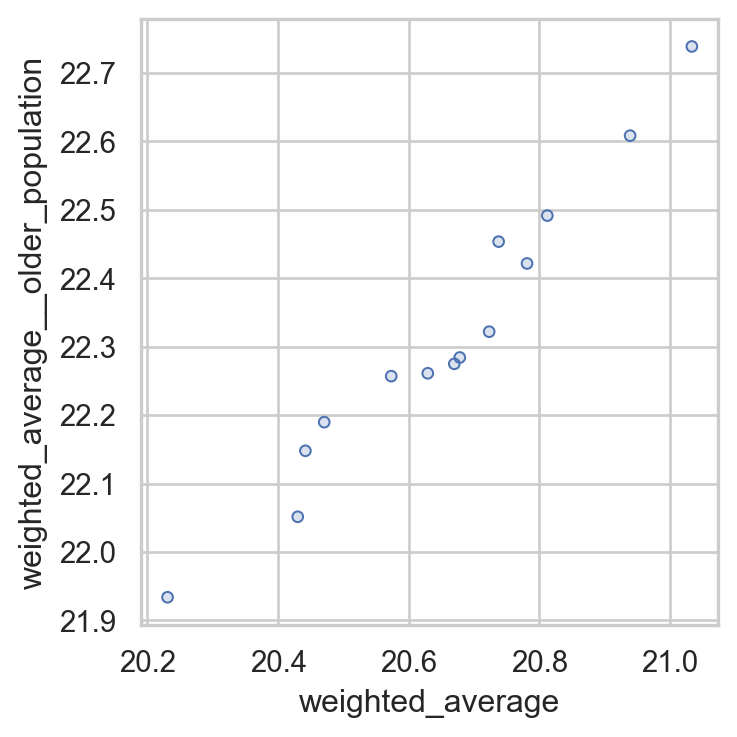

In [8]:
solution.plot_simple_pareto_front_pairs(
    x_axis="weighted_average",
    y_axis="weighted_average__older_population",
    )

Because both demand scenarios' metrics live on the same ranked list, we can trade them off directly with the same Pareto tooling used elsewhere (see [the Pareto fronts example](../multiobjective_optimisation_pareto/index.ipynb)) -- there's nothing secondary-demand-specific about `compute_pareto_front()`, it just consumes whichever `solution_df` columns you point it at.

In [9]:
from lokigi.multiobjective import Metric

metrics = [
    Metric(column="weighted_average", direction="lower_better",
                 label="whole-population weighted average travel time", unit="minutes"),
    Metric(column="max", direction="lower_better",
                    label="max travel time", unit="minutes"),
        Metric(column="weighted_average__older_population", direction="lower_better",
                 label="older-population weighted average travel time", unit="minutes"),
    ]

solution.compute_pareto_front(metrics=metrics)
solution.pareto_summary()

,solution_rank,weighted_average,max,weighted_average__older_population
0,1,20.230707,61.533333,21.933916
1,3,20.441737,61.183334,22.147958


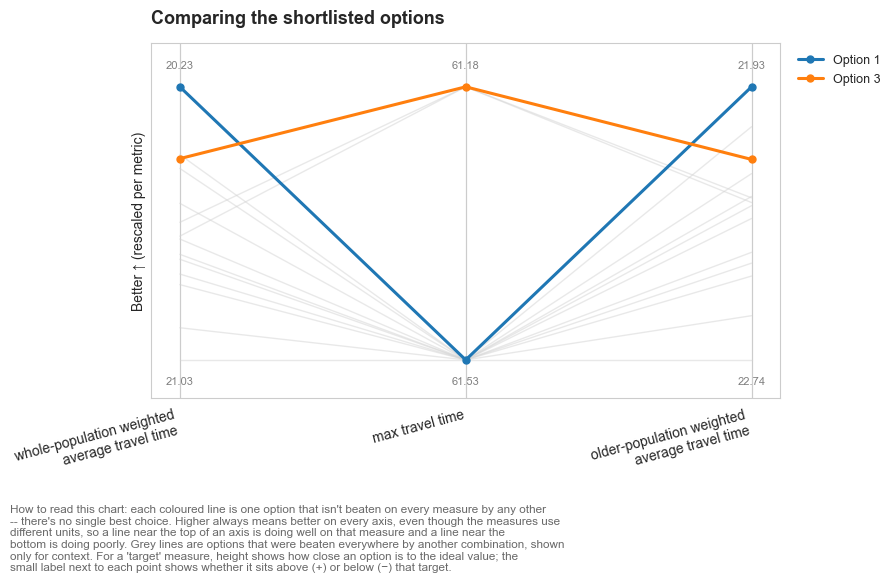

In [10]:
solution.plot_pareto_summary(width_multiplier=3);

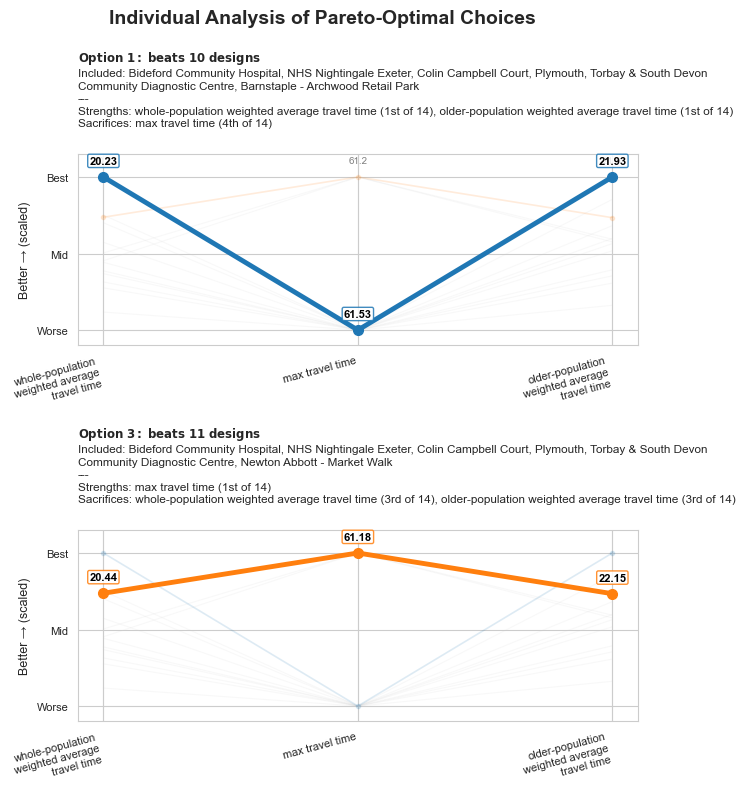

In [11]:
solution.plot_pareto_facets();

## Blending scenarios with `weights=`

Instead of keeping the two scenarios as separate Pareto objectives, we can blend them into a single composite objective by passing a secondary demand scenario's label as a `weights=` key -- exactly like `demand`, `equity`, or an additional dataset's label. Each demand vector is min-max normalised before blending, so this weights *how much influence each scenario's spatial pattern has*, not their raw population totals.

In [12]:
solution_blended = problem.solve(
    p=5,
    threshold_for_coverage=30,
    weights={"demand": 0.5, "older_population": 0.5},
    )
solution_blended.show_solutions()[["site_names", "weighted_average"]].head(3)

  0%|          | 0/14 [00:00<?, ?it/s]

,site_names,weighted_average
0,"[Bideford Community Hospital, NHS Nightingale ...",21.81
1,"[Bideford Community Hospital, NHS Nightingale ...",21.85
2,"[Bideford Community Hospital, NHS Nightingale ...",21.98


## Scoring accessibility under a chosen scenario

`two_step_floating_catchment()`, `site_allocation_summary()`, and the demand-facing plots all gain a `demand=<label>` argument, mirroring the existing `matrix=<label>` argument used to switch between travel matrices -- pass a registered secondary demand scenario's label to score or plot under that scenario instead of the primary.

In [13]:
accessibility_total = problem.two_step_floating_catchment(
    supply_col="capacity",
    catchment_size=30,
    )

accessibility_older = problem.two_step_floating_catchment(
    supply_col="capacity",
    catchment_size=30,
    demand="older_population",
    )

accessibility_total[["accessibility", "demand"]].join(
    accessibility_older[["accessibility", "demand"]],
    lsuffix="_total_pop", rsuffix="_older_pop"
    ).head()

,accessibility_total_pop,demand_total_pop,accessibility_older_pop,demand_older_pop
LSOA 2021 Name,,,,
Plymouth 001A,0.000088,1712,0.000210,850.0
Plymouth 002A,0.000088,1669,0.000210,698.0
Plymouth 003A,0.000026,1750,0.000073,630.0
Plymouth 003B,0.000026,1493,0.000073,498.0
Plymouth 003C,0.000026,1740,0.000073,444.0


`site_allocation_summary()` takes the same `demand=` argument, reporting each selected site's share of demand (and average travel cost) under the chosen scenario instead of the primary.

In [14]:
solution.site_allocation_summary(by="demand", demand="older_population").round(3)

,n_regions,allocated_demand,proportion,average_travel_cost
site,,,,
Bideford Community Hospital,43,38717.0,0.075,23.142
NHS Nightingale Exeter,253,183759.0,0.354,25.861
"Colin Campbell Court, Plymouth",216,138698.0,0.267,19.856
Torbay & South Devon Community Diagnostic Centre,156,111412.0,0.214,18.786
Barnstaple - Archwood Retail Park,61,46907.0,0.090,19.174


## A note on secondary travel matrices

If a problem also has one or more **secondary travel matrices** registered (see [the multiple travel matrices example](../multiple_travel_matrices/index.ipynb)), a secondary demand scenario by default only re-weights the *primary* travel matrix -- keeping the added output additive rather than multiplying every demand scenario against every travel matrix. To opt a scenario into also weighting a specific secondary travel matrix, pass its label via `also_weight_matrices`:

```python
problem.add_secondary_demand(
    ...,
    label="older_population",
    also_weight_matrices=["public_transport"],
    )
```

This produces `weighted_average__public_transport__older_population` and `proportion_within_coverage_threshold__public_transport__older_population` columns -- just for that named combination, not every combination.

## Which approach should I use?

- **Secondary demand scenarios** (this example): one `solve()`, one ranked list, with every registered scenario's metrics available side by side. Best when you want to explore trade-offs *between* demand definitions for the same candidate solutions -- e.g. with a Pareto front, or by weighting them into a single composite objective.
- **`problem.copy()` + `SolutionComparator`** (see [the comparing solutions example](../comparing_solutions/index.ipynb)): two independent solves, each optimised (and pruned) entirely on its own demand definition. Best when the two scenarios genuinely need separate optimisations, and you want `find_balanced_solution()`'s rank-overlap heuristic to reconcile them afterwards.